# Step 1 - Camera Calibration

First, we need a calibration clip to get camera parameters.  The calibration clip should have a checker board pattern that moves around on the chute floor.

In [1]:
from ipywidgets import Video
Video.from_file("./videos/calibration2.mp4", width=640)

Video(value=b'\x00\x00\x00\x1cftypisom\x00\x00\x02\x00isomiso2mp41\x00\x00\x00\x08free\x00\xec\xb7\xd7mdat\x82…

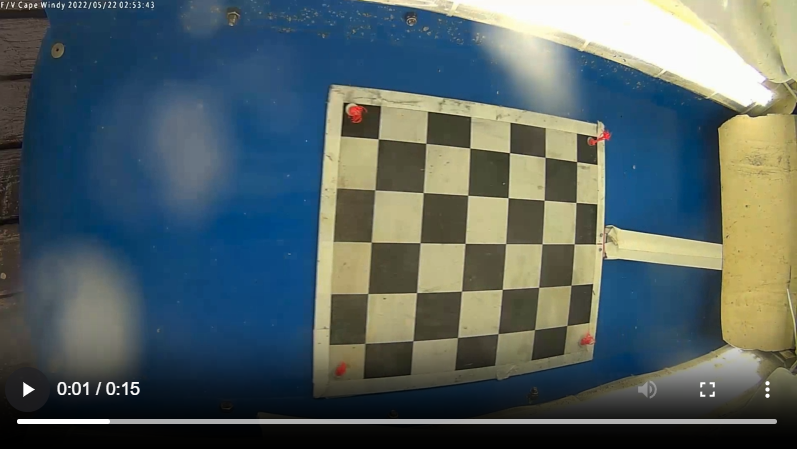

To perform the camera calibration, we use the ../calibrate/UWEE_chute_calibration.exe executable to produce a calibration file.  To use this executable, we also need to make sure the CamCalibBEV section of the calibration parameters is correct at ../calibrate/configChuteCalibration.yml.
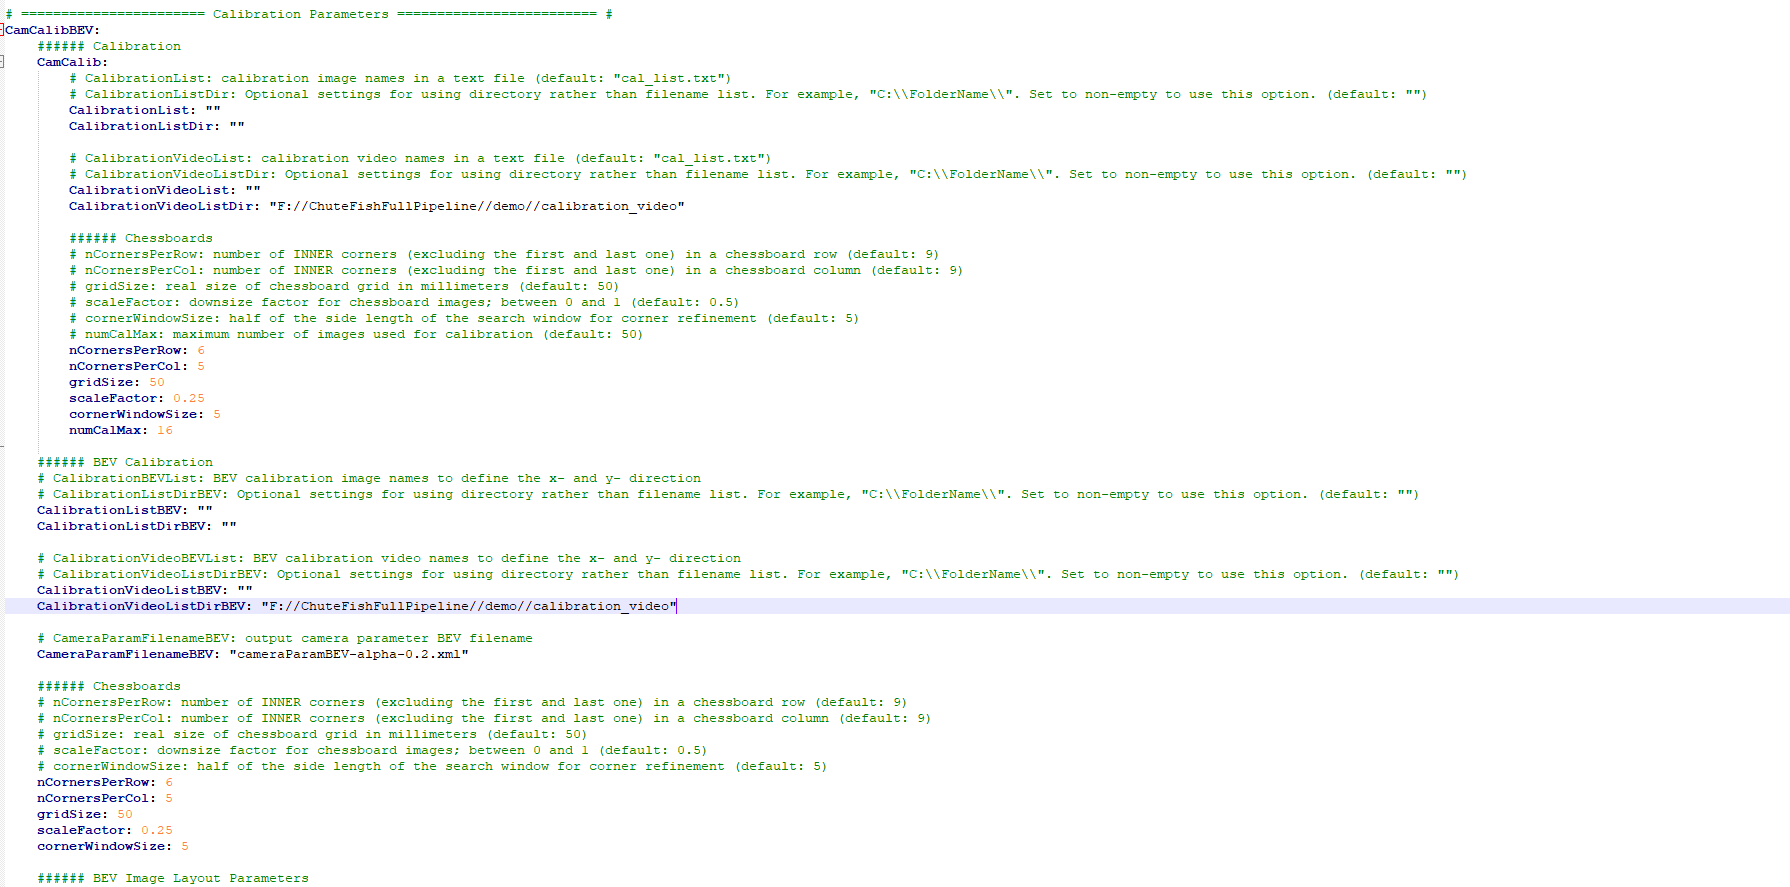



Run the terminal command and choose option 6 for camera calibration.  NOTE - this executable should only be used to generate camera calibration files.  The other options are outdated.

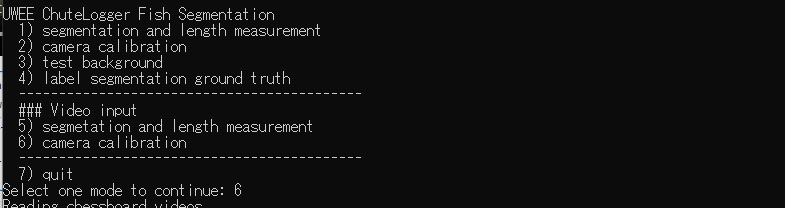

In [2]:
%%cmd
"../calibrate/UWEE_chute_calibration.exe" ../calibrate/configChuteCalibration.yml
6

Microsoft Windows [Version 10.0.19045.4894]
(c) Microsoft Corporation. All rights reserved.

F:\ChuteFishFullPipeline\demo>"../calibrate/UWEE_chute_calibration.exe" ../calibrate/configChuteCalibration.yml
Using configuration file: ../calibrate/configChuteCalibration.yml
CamCalibBEV > CamCalib > CalibrationList: 
CamCalibBEV > CamCalib > CalibrationListDir: 
CamCalibBEV > CamCalib > CalibrationVideoList: 
CamCalibBEV > CamCalib > CalibrationVideoListDir: //content//ChuteFishFullPipeline//chute demo//calibration_video
CamCalibBEV > CamCalib > [ - ERROR - ] Cannot find the node: CameraParamFilename
CamCalibBEV > CamCalib > nCornersPerRow: 6
CamCalibBEV > CamCalib > nCornersPerCol: 5
CamCalibBEV > CamCalib > gridSize: 50
CamCalibBEV > CamCalib > scaleFactor: 0.25
CamCalibBEV > CamCalib > cornerWindowSize: 5
CamCalibBEV > CamCalib > numCalMax: 16
CamCalibBEV > CalibrationListBEV: 
CamCalibBEV > CalibrationListDirBEV: 
CamCalibBEV > CalibrationVideoListBEV: 
CamCalibBEV > CalibrationVideoLis

The calibration file should be saved to F:\ChuteFishFullPipeline\demo\calibration\cameraParamBEV-alpha-0.2.xml.

# Step 2 - Undistort Video
Convert video to bird's eye view (BEV) so that pixel length corresponds to real length in meters.  Here is our test video.

In [2]:
Video.from_file("./test_video/test2.mp4", width=640)

Video(value=b'\x00\x00\x00\x1cftypisom\x00\x00\x02\x00isomiso2mp41\x00\x00\x00\x08free\x00\x19x\xcbmdat\x82I\x…

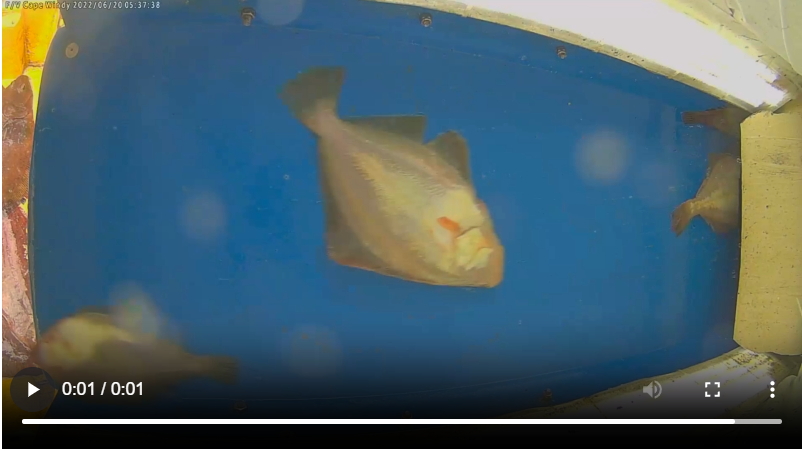

Set the configuration file so that our program knows where to find the input video, where to save the output results, and where the calibration file is.
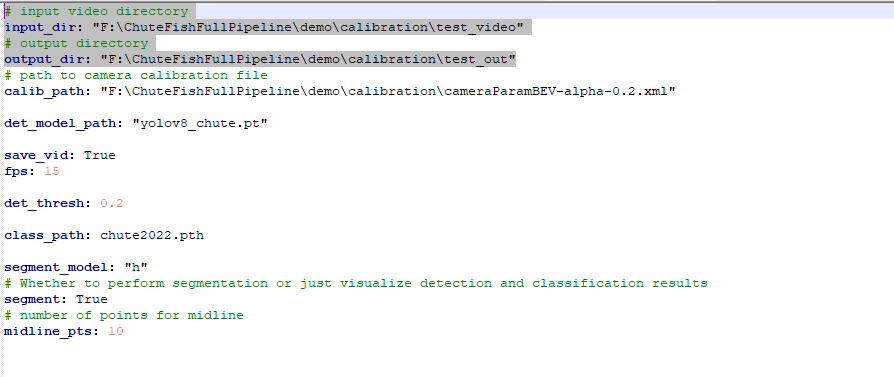


In [19]:
%%cmd
python ../calibrate/undistort_videos.py --config_path demoChuteConfig.yml

Microsoft Windows [Version 10.0.19045.4529]
(c) Microsoft Corporation. All rights reserved.

(yolov8) F:\ChuteFishFullPipeline\demo>python ../calibrate/undistort_videos.py --config_path demoChuteConfig.yml
Undistortion code running now
Processing video test2.mp4


OpenCV: FFMPEG: tag 0x30395056/'VP90' is not supported with codec id 167 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x39307076/'vp09'


Undistorting video 1/1: frame 30/32
(yolov8) F:\ChuteFishFullPipeline\demo>

Now the BEV video should be at F:\ChuteFishFullPipeline\demo\test_out\undistorted

In [3]:
from ipywidgets import Video
Video.from_file("./test_out/undistorted/test2.mp4", width=640)

Video(value=b'\x00\x00\x00\x1cftypisom\x00\x00\x02\x00isomiso2mp41\x00\x00\x00\x08free\x00\x0f\x97Hmdat\x82I\x…

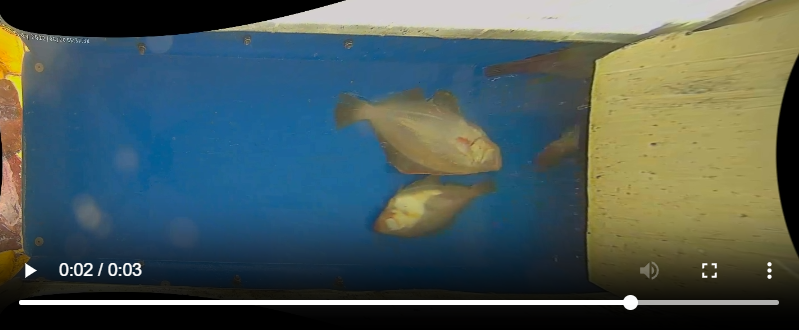

# Step 3 - Detection and Tracking
Now that we have our BEV video, we can use our yolov8 model to detect any fish in the video and associate them into tracks with DeepSORT.  Make sure that the detection model path, confidence threshold, and visualization parameters are set.
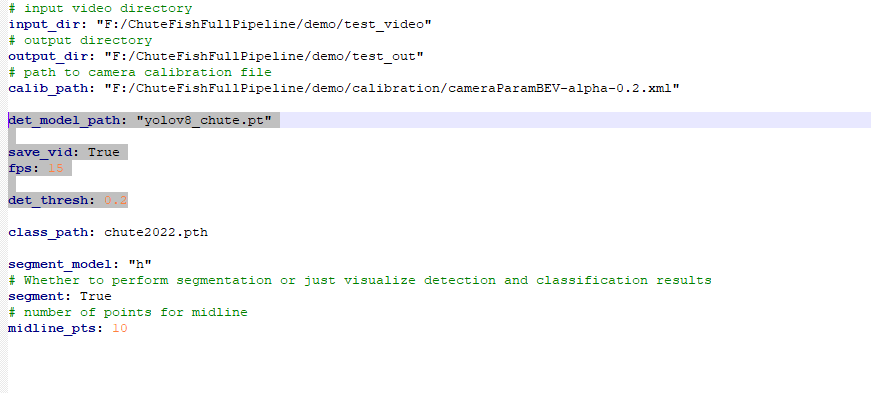

We need to navigate to the detection director in order to run the code without errors.

In [20]:
%%cmd
cd ../detection
python track.py --config_path ../demo/demoChuteConfig.yml

Microsoft Windows [Version 10.0.19045.4529]
(c) Microsoft Corporation. All rights reserved.

(yolov8) F:\ChuteFishFullPipeline\demo>cd ../detection

(yolov8) F:\ChuteFishFullPipeline\detection>python track.py --config_path ../demo/demoChuteConfig.yml


F:\ChuteFishFullPipeline\detection\deep_sort/deep/reid\torchreid\metrics\rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(
YOLOv5  e1c5877 torch 1.10.1 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)

YOLOv5  e1c5877 torch 1.10.1 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)



../demo/demoChuteConfig.yml
0.5

0: 1088x1088 (no detections), 22.0ms
Speed: 0.0ms preprocess, 22.0ms inference, 3.0ms postprocess per image at shape (1, 3, 1088, 1088)


video 1/1 (1/32) F:\ChuteFishFullPipeline\demo\test_out\undistorted\test2.mp4: 480x1088 1 fish, Done. YOLO:(0.025s), Tracking:(0.025s)
video 1/1 (2/32) F:\ChuteFishFullPipeline\demo\test_out\undistorted\test2.mp4: 480x1088 2 fishs, Done. YOLO:(0.017s), Tracking:(0.029s)
video 1/1 (3/32) F:\ChuteFishFullPipeline\demo\test_out\undistorted\test2.mp4: 480x1088 2 fishs, Done. YOLO:(0.016s), Tracking:(0.026s)
video 1/1 (4/32) F:\ChuteFishFullPipeline\demo\test_out\undistorted\test2.mp4: 480x1088 1 fish, Done. YOLO:(0.016s), Tracking:(0.028s)
video 1/1 (5/32) F:\ChuteFishFullPipeline\demo\test_out\undistorted\test2.mp4: 480x1088 1 fish, Done. YOLO:(0.018s), Tracking:(0.024s)
video 1/1 (6/32) F:\ChuteFishFullPipeline\demo\test_out\undistorted\test2.mp4: 480x1088 2 fishs, Done. YOLO:(0.017s), Tracking:(0.024s)
video 1/1 (7/32) F:\ChuteFishFullPipeline\demo\test_out\undistorted\test2.mp4: 480x1088 1 fish, Done. YOLO:(0.017s), Tracking:(0.023s)
video 1/1 (8/32) F:\ChuteFishFullPipeline\demo\test_

Successfully loaded imagenet pretrained weights from "C:\Users\aotia/.cache\torch\checkpoints\osnet_x0_25_imagenet.pth"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']
Model: osnet_x0_25
- params: 203,568
- flops: 82,316,000
Results saved to F:\ChuteFishFullPipeline\demo\test_out\detection\test2.mp4


OpenCV: FFMPEG: tag 0x30395056/'VP90' is not supported with codec id 167 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x39307076/'vp09'



(yolov8) F:\ChuteFishFullPipeline\detection>

The detection and tracking results should be saved to  F:\ChuteFishFullPipeline\demo\test_out\detection

In [4]:
from ipywidgets import Video
Video.from_file("./test_out/detection/test2.mp4", width=640)

Video(value=b'\x00\x00\x00\x1cftypisom\x00\x00\x02\x00isomiso2mp41\x00\x00\x00\x08free\x00\x10\xbe*mdat\x82I\x…

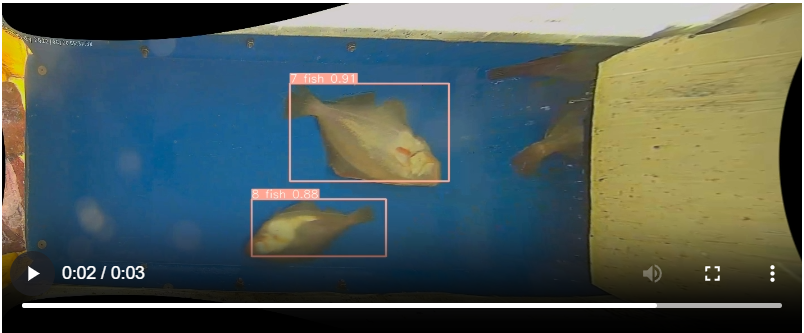

# Step 4 - Species ID
Once we have our fish bounding boxes, we crop our the fish images and feed them to a classifier for species ID.  In the config file, specify the classification model path.
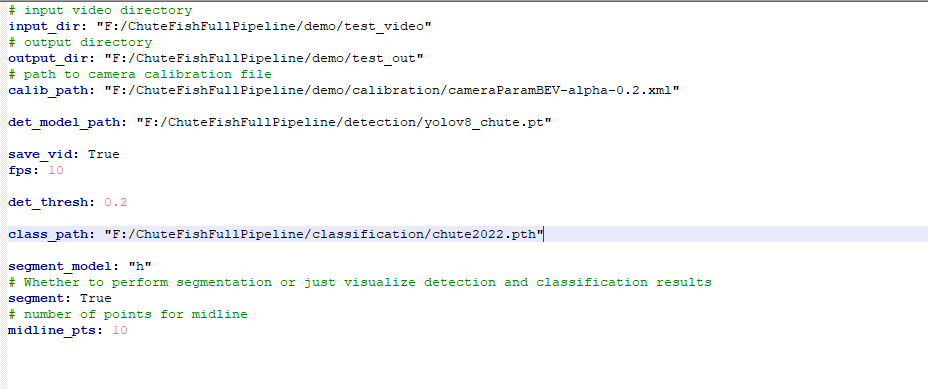

In [22]:
%%cmd
cd ../classification
python test.py --config_path ../demo/demoChuteConfig.yml

Microsoft Windows [Version 10.0.19045.4529]
(c) Microsoft Corporation. All rights reserved.

(yolov8) F:\ChuteFishFullPipeline\demo>cd ../classification

(yolov8) F:\ChuteFishFullPipeline\classification>python test.py --config_path ../demo/demoChuteConfig.yml
Classification code running now
Processing video test2.mp4
classifying video 1/1: frame 30/32
(yolov8) F:\ChuteFishFullPipeline\classification>

In [5]:
from ipywidgets import Video
Video.from_file("./test_out/classification/test2.mp4", width=640)

Video(value=b'\x00\x00\x00\x1cftypisom\x00\x00\x02\x00isomiso2mp41\x00\x00\x00\x08free\x00\x14;\xa0mdat\x82I\x…

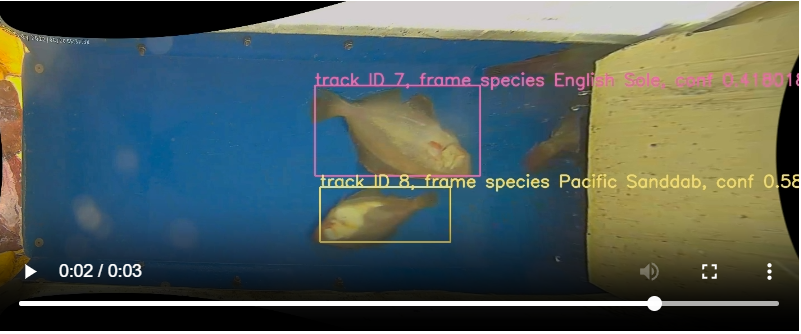

# Step 5 - Segmentation and Length Estimation
We use the Segment Anything (SAM) zero-shot segmentation model to get fish segmentation mask.  Using the masks, we can perform midline estimation and use the length of the midline to get fish length.  Since segmentation takes a long time, we have the option in our configs to skip segmentation and length estimation.  In this case, the output will just be the tracked based detection and species ID results.  If we opt to perform length estimation, the number of midline points determines how sensitive the midline is to the fishes' body shape.  If this is set too high, our length estimate will be too large due to midline not being straight.
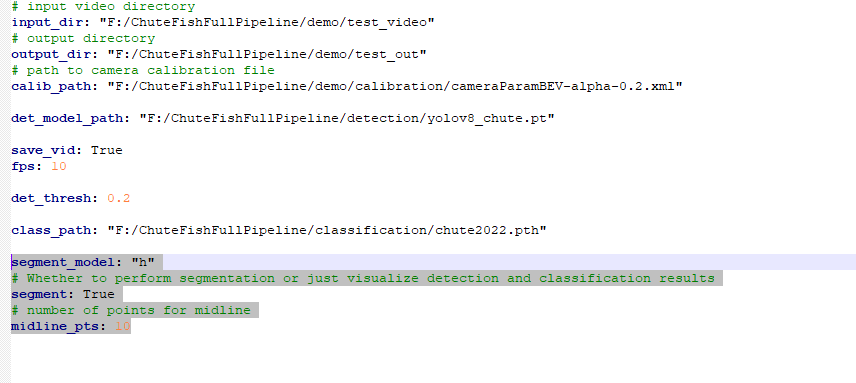

You can download the SAM models from https://github.com/facebookresearch/segment-anything

In [24]:
%%cmd
cd ../segmentation
python segment.py --config_path ../demo/demoChuteConfig.yml

Microsoft Windows [Version 10.0.19045.4529]
(c) Microsoft Corporation. All rights reserved.

(yolov8) F:\ChuteFishFullPipeline\demo>cd ../segmentation

(yolov8) F:\ChuteFishFullPipeline\segmentation>python segment.py --config_path ../demo/demoChuteConfig.yml
Segmenting video test2.mp4


OpenCV: FFMPEG: tag 0x39305056/'VP09' is not supported with codec id 167 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x39307076/'vp09'


 Segmenting video 1/1: frame 33, avg seconds per frame: 1.053
(yolov8) F:\ChuteFishFullPipeline\segmentation>

In [6]:
from ipywidgets import Video
Video.from_file("./test_out/segmentation/test2.mp4", width=640)

Video(value=b'\x00\x00\x00\x1cftypisom\x00\x00\x02\x00isomiso2mp41\x00\x00\x00\x08free\x00\x11\xf5Qmdat\x82I\x…

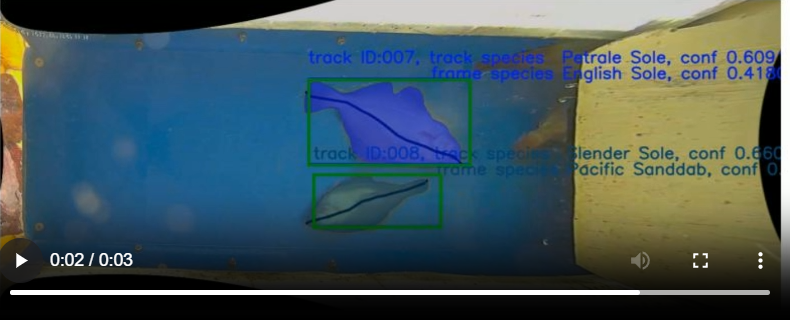